# **Training Data In machine Learning**

## **Introduction:**

In this assignment, we will explore key aspects of training data management in machine learning, including sampling techniques, class imbalance, data labeling, and model performance evaluation.

## **1. Import and Explore the Wine dataset**

In [57]:
# Import and load the dataset

from sklearn.datasets import load_wine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

wine = load_wine()

In [50]:
# Convert to a DataFrame

wine_data = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add the target/class column
wine_data["target"] = wine.target

wine_data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [51]:
# Check the class distribution

wine_data["target"].value_counts().sort_index()

target
0    59
1    71
2    48
Name: count, dtype: int64

## **2. Apply Sampling Techniques**

#### **2.1 Simple random sampling**

In [3]:
# Sampling 50 observations using Simple Random Sampling

wine_random_sample = wine_data.sample(n=50, random_state=42)

wine_random_sample.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,0
45,14.21,4.04,2.44,18.9,111.0,2.85,2.65,0.30,1.25,5.24,0.87,3.33,1080.0,0
140,12.93,2.81,2.70,21.0,96.0,1.54,0.50,0.53,0.75,4.60,0.77,2.31,600.0,2
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0,0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0,1


In [6]:
# Check the class distribution

wine_random_sample["target"].value_counts().sort_index()

target
0    17
1    20
2    13
Name: count, dtype: int64

#### **2.2 Stratified sampling**

In [ ]:
# Stratified sample of 50 observations

stratified_sample, _ = train_test_split(
    wine_data,
    train_size=50,
    stratify=wine_data["target"],
    random_state=42)

# Check the class distribution

stratified_sample["target"].value_counts().sort_index()

target
0    17
1    20
2    13
Name: count, dtype: int64

#### **2.3 Visualize the class distribution** 

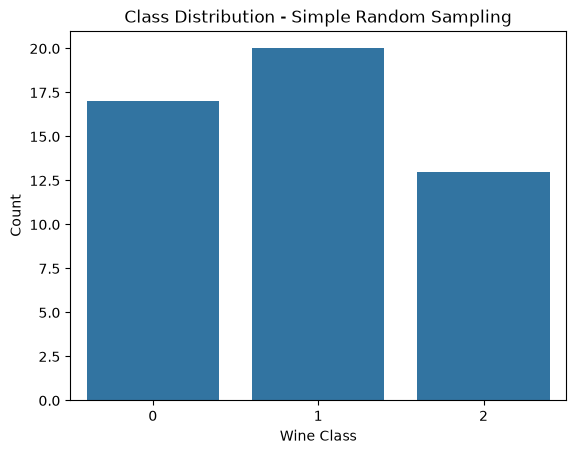

In [ ]:
# Visualize the class distribution_Simple random sampling


sns.countplot(data=wine_random_sample, x="target")

plt.title("Class Distribution - Simple Random Sampling")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()


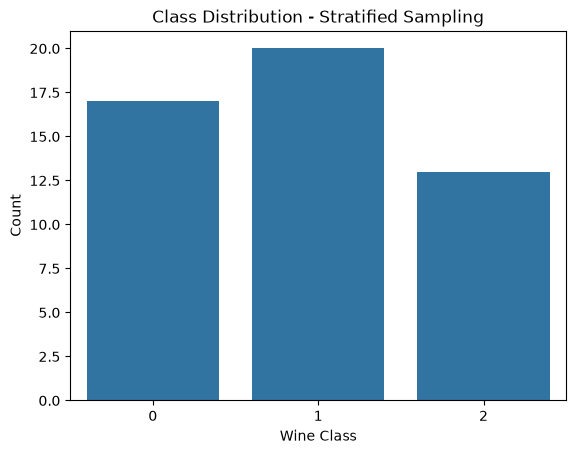

In [ ]:
# Visualize the class_Stratified sampling

sns.countplot(data=stratified_sample, x="target")

plt.title("Class Distribution - Stratified Sampling")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()

## **3.Handle Class Imbalance**

### **3.1 Create an imbalanced dataset**

In [ ]:
# Separate the classes

class_0 = wine_data[wine_data["target"] == 0]
class_1 = wine_data[wine_data["target"] == 1]
class_2 = wine_data[wine_data["target"] == 2]

# Reduce Class 2 to only 10 observations

class_2_reduced = class_2.sample(n=10, random_state=42)

# Combine the classes

imbalanced_data = pd.concat([class_0, class_1, class_2_reduced])

# Check distribution

imbalanced_data["target"].value_counts()

target
1    71
0    59
2    10
Name: count, dtype: int64

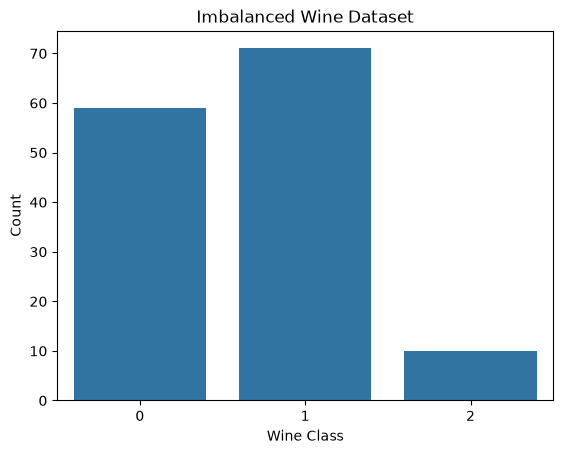

In [ ]:
# Visualize class imbalance

sns.countplot(data=imbalanced_data, x="target")
plt.title("Imbalanced Wine Dataset")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()


#### **3.2 Apply SMOTE**

In [17]:
# Separate features and target

X = imbalanced_data.drop("target", axis=1)
y = imbalanced_data["target"]

In [19]:
# Split the data before applying SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42)

In [21]:
# Apply SMOTE

import sys
!{sys.executable} -m pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Apply SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
target
1    50
0    41
2     7
Name: count, dtype: int64

After SMOTE:
target
0    50
1    50
2    50
Name: count, dtype: int64


#### **3.3 Train Random Forest on the imbalanced data** 

In [26]:
# Train the Random Forest Classifier

rf_imbalanced = RandomForestClassifier(random_state=42)

rf_imbalanced.fit(X_train, y_train)

y_pred_imbalanced = rf_imbalanced.predict(X_test)

print("Random Forest for Imbalanced Data")
print(classification_report(y_test, y_pred_imbalanced))

Random Forest for Imbalanced Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00         3

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



#### **3.4 Train Random Forest on the SMOTE-balanced data**

In [27]:
# Train the Random Forest Classifier 

rf_balanced = RandomForestClassifier(random_state=42)

rf_balanced.fit(X_train_balanced, y_train_balanced)

y_pred_balanced = rf_balanced.predict(X_test)

print("Random Forest - SMOTE Balanced Data")
print(classification_report(y_test, y_pred_balanced))

Random Forest - SMOTE Balanced Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00         3

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



##### **Insights**
Both models achieved perfect precision, recall, and F1-scores (1.00). SMOTE showed no improvement because the original Random Forest already classified all test observations correctly. However, with only three minority-class observations in the test set, cross-validation would used to compare the performance.

## **4. Labeling Data Using Heuristics**

In [33]:
# Check the alcohol values

wine_data["alcohol"].describe()

count    178.000000
mean      13.000618
std        0.811827
min       11.030000
25%       12.362500
50%       13.050000
75%       13.677500
max       14.830000
Name: alcohol, dtype: float64

#### **4.1 Create the heuristic labels**

Rule: 
Alcohol ≥ 13: High Alcohol
Alcohol < 13: Low Alcohol

In [36]:
# Check the distribution

wine_data["heuristic_label"].value_counts()

heuristic_label
High Alcohol    92
Low Alcohol     86
Name: count, dtype: int64

In [42]:
# Create heuristic labels 

wine_data["Alcohol_heuristic_label"] = wine_data["alcohol"].apply(
    lambda x: "High Alcohol" if x >= 13 else "Low Alcohol")

wine_data[["alcohol", "target", "Alcohol_heuristic_label"]].head()

,alcohol,target,Alcohol_heuristic_label
0,14.23,0,High Alcohol
1,13.20,0,High Alcohol
2,13.16,0,High Alcohol
3,14.37,0,High Alcohol
4,13.24,0,High Alcohol


## **5. Evaluate Model Performance**

### **5.1 Identify features and target from original dataset**

In [52]:
wine_data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [53]:
X = wine_data[wine.feature_names]
y = wine_data["target"]

### **5.2 Split data into training and test sets**

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42)

### **5.3 Train the Decision Tree**

In [55]:
# Train the dt

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### **5.4 Get predicted probabilities**

In [56]:
y_prob = dt_model.predict_proba(X_test)

### **5.5 Calculate AUC**

In [ ]:
auc_score = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro")

print("Macro-average AUC:", auc_score)

Macro-average AUC: 0.9695286195286196


### **5.6 Plot the ROC curves**

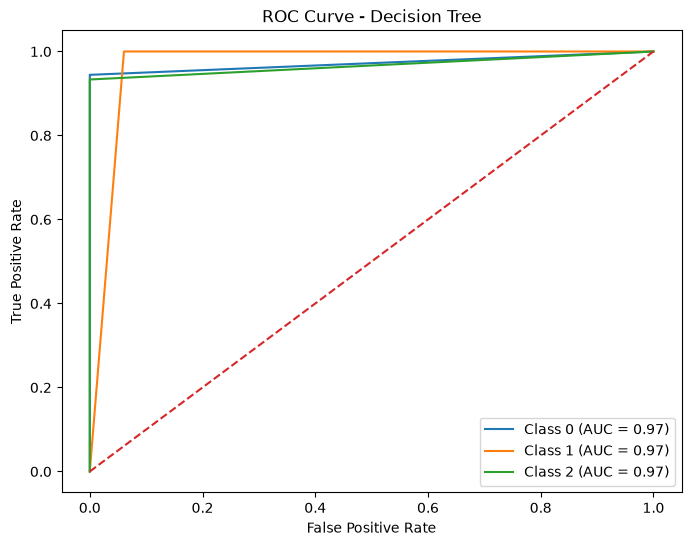

In [59]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert target into binary format for each class
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {class_auc:.2f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

# **Insights:**

The Decision Tree achieved a macro-average AUC of 0.970, indicating excellent overall ability to distinguish among the three wine classes. The ROC curves were close to the top-left corner and well above the random classifier line. Overall, the model demonstrated strong classification performance across all classes.